In [1]:

import logging
from pathlib import Path

import numpy as np
import polars as pl
# from decimal import Decimal
from datetime import datetime, timezone

import matplotlib.pyplot as plt
from scipy import stats


In [2]:

class AvailableDatasets:
    """Available Datasets, returns request ID"""

    FULL_YEAR_2024__CME_JPY_V: str = "GLBX-20251028-HAE9P7SP3U"
    FULL_YEAR_2023__CME_JPY_V: str = "GLBX-20251116-MJ5JKQA9A4"
    FULL_YEAR_2022__CME_JPY_V: str = "GLBX-20251115-DJHUGKSLWB"


In [3]:

# WORKING DIRECTORY
MAIN_DIR = Path("/Users/number6/Projects/Bimini/")

# HISTORICAL DATA
HISTORICAL_DATA = MAIN_DIR / "0_data" / "historical"

# IMPORT PATH
PARQUET_DIR = HISTORICAL_DATA / "parquet"

# EXPORT PATH
EXPORT_DIR = MAIN_DIR / "journal_results"


In [4]:
# ============================================================================
# [START] - Import Filters
# ============================================================================


# Convert START_DATE and END_DATE to nanosecond epochs (integers)
START_DATE_NS = int(datetime(2022, 1, 1, tzinfo=timezone.utc).timestamp() * 1e9)
END_DATE_NS   = int(datetime(2025, 1, 1, tzinfo=timezone.utc).timestamp() * 1e9)
# END_DATE_NS   = int(datetime(2025, 1, 1, tzinfo=timezone.utc).timestamp() * 1e9)


# # Data files to glob for processing
# DATA_GLOB = pl.scan_parquet(str(PARQUET_DIR / request_id / "*.parquet"))

# Method 2: List of glob patterns for MULTIPLE DIRECTORIES
DATA_GLOB = pl.scan_parquet([
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2022__CME_JPY_V / "*.parquet"),
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2023__CME_JPY_V / "*.parquet"),
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2024__CME_JPY_V / "*.parquet"),
])


# [ ACTUAL FILTER REQUEST FOR PROCESSING ]
lf = (

    # 0) Glob across all files in data directory
    DATA_GLOB
    
    # 1) Select only needed columns FIRST (reduces data volume)
    .select([
        "ts_recv",
        "price",
        "size",
        "side",
        "sequence",
        "instrument_id",
    ])

    # 2.) Convert to physical int representation (just stripping data, saved as int64 in Parquet file)
    .with_columns(
        pl.col("ts_recv").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("ts_recv"),
        pl.col("side").cast(pl.Categorical)
    )
    
    # 3) Filter on raw uint64 epoch values (fastest)
    .filter(
        (pl.col("ts_recv") >= START_DATE_NS) & 
        (pl.col("ts_recv") < END_DATE_NS)
    )
    .filter(pl.col("side").is_in(["A", "B"])) # Remove "N" side orders
    # .limit(1_000)

)

In [5]:
vwap = lf.with_columns(

    pl.col("ts_recv").cast(pl.Datetime("ns"))

).group_by_dynamic(

    "ts_recv",
    every="30m"

).agg(

    buy_vwap=(pl.col("size").filter(pl.col("side") == "B") * pl.col("price").filter(pl.col("side") == "B")).sum() / pl.col("size").filter(pl.col("side") == "B").sum(),
    sell_vwap=(pl.col("size").filter(pl.col("side") == "A") * pl.col("price").filter(pl.col("side") == "A")).sum() / pl.col("size").filter(pl.col("side") == "A").sum(),
    total_vwap=(pl.col("size") * pl.col("price")).sum() / pl.col("size").sum(),

).with_columns(

    spread=pl.col("buy_vwap") - pl.col("sell_vwap"),
    prev_total_vwap=pl.col("total_vwap").shift(1),
    total_vwap_change=pl.col("total_vwap") - pl.col("total_vwap").shift(1),
    pct_return=(pl.col("total_vwap") - pl.col("total_vwap").shift(1)) / pl.col("total_vwap").shift(1),

    # log(price_t) - log(price_t-1) = log(price_t / price_t-1) -> subtraction is more efficient
    log_return=pl.col("total_vwap").log() - pl.col("total_vwap").shift(1).log()

).select([
    
    "ts_recv",
    "buy_vwap",
    "sell_vwap",
    "total_vwap",
    "spread",
    "prev_total_vwap",
    "total_vwap_change",
    "pct_return",
    "log_return",

]).collect()


In [6]:
def compare_distributions(returns):

    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Histogram with normal distribution overlay
    ax1 = axes[0]
    ax1.hist(returns, bins=200, density=True, alpha=0.7, edgecolor='black', label='Actual Returns')

    # Fit normal distribution to the data
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 100)
    normal_dist = stats.norm.pdf(x, mu, sigma)
    ax1.plot(x, normal_dist, 'r-', linewidth=2, label=f'Normal(μ={mu:.4f}, σ={sigma:.4f})')

    ax1.set_xlabel('Returns')
    ax1.set_ylabel('Density')
    ax1.set_title('Returns Distribution vs Normal Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Q-Q plot
    ax2 = axes[1]
    stats.probplot(returns, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"Mean: {mu:.6f}")
    print(f"Std Dev: {sigma:.6f}")
    print(f"Skewness: {stats.skew(returns):.4f}")
    print(f"Kurtosis: {stats.kurtosis(returns):.4f}")
    print(f"Jarque-Bera test: statistic={stats.jarque_bera(returns)[0]:.4f}, p-value={stats.jarque_bera(returns)[1]:.4f}")



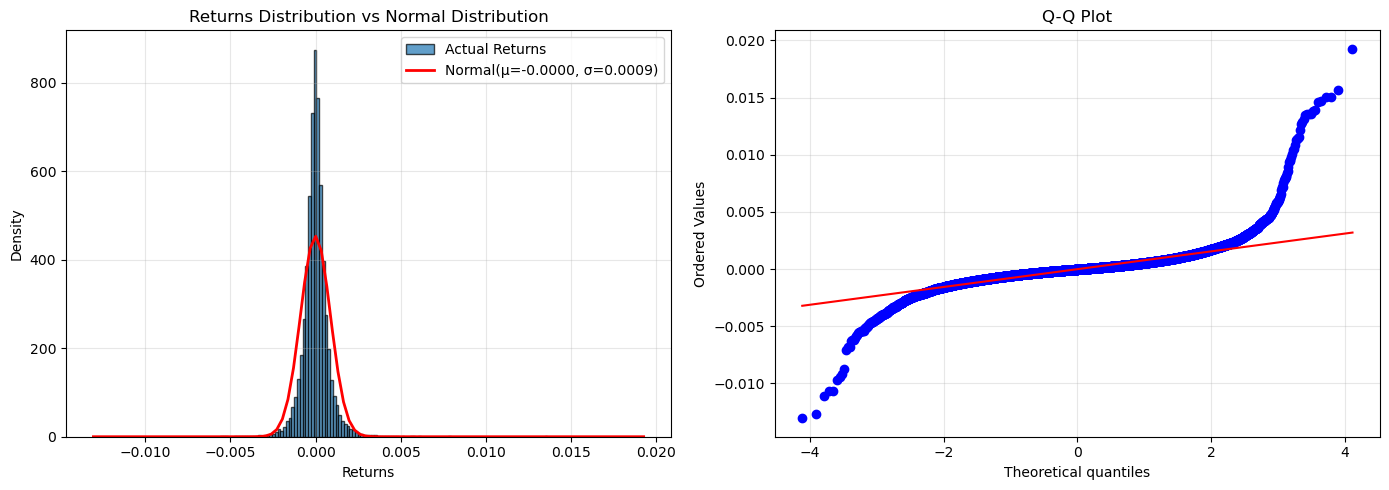

Mean: -0.000009
Std Dev: 0.000881
Skewness: 2.4279
Kurtosis: 51.9140
Jarque-Bera test: statistic=4025856.6696, p-value=0.0000


In [7]:
# Extract returns column (assuming it's already calculated)
timebar_returns = vwap["log_return"].drop_nulls().to_numpy()

compare_distributions(timebar_returns)

In [8]:

"""
get vwap per interval
then calc returns, pct/log

aggregate vwap time series, 1, 5, 15min

versus 100_VB size, add VBs? for other multiples?

"""

'\nget vwap per interval\nthen calc returns, pct/log\n\naggregate vwap time series, 1, 5, 15min\n\nversus 100_VB size, add VBs? for other multiples?\n\n'

In [9]:

VB100_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_ib1500/2214_Nov_15_25/volumebar/raw/volumebar_raw_consolidated.parquet")

# ============================================================================
# [START] - Import Filters
# ============================================================================


# Convert START_DATE and END_DATE to nanosecond epochs (integers)
START_DATE_NS = int(datetime(2022, 1, 1, tzinfo=timezone.utc).timestamp() * 1e9)
END_DATE_NS   = int(datetime(2025, 1, 1, tzinfo=timezone.utc).timestamp() * 1e9)
# END_DATE_NS   = int(datetime(2025, 1, 1, tzinfo=timezone.utc).timestamp() * 1e9)


# Data files to glob for processing
VB_DATA_GLOB = pl.scan_parquet(str(VB100_DIR))


# {VolumeBar 100} [ ACTUAL FILTER REQUEST FOR PROCESSING ]
# vb_lf = VB_DATA_GLOB.select([
    
#     "id",
#     "delta_midpoint_vwap_pct",
#     "delta_midpoint_vwap_log",

# ]).collect()

vb_lf = VB_DATA_GLOB.collect()




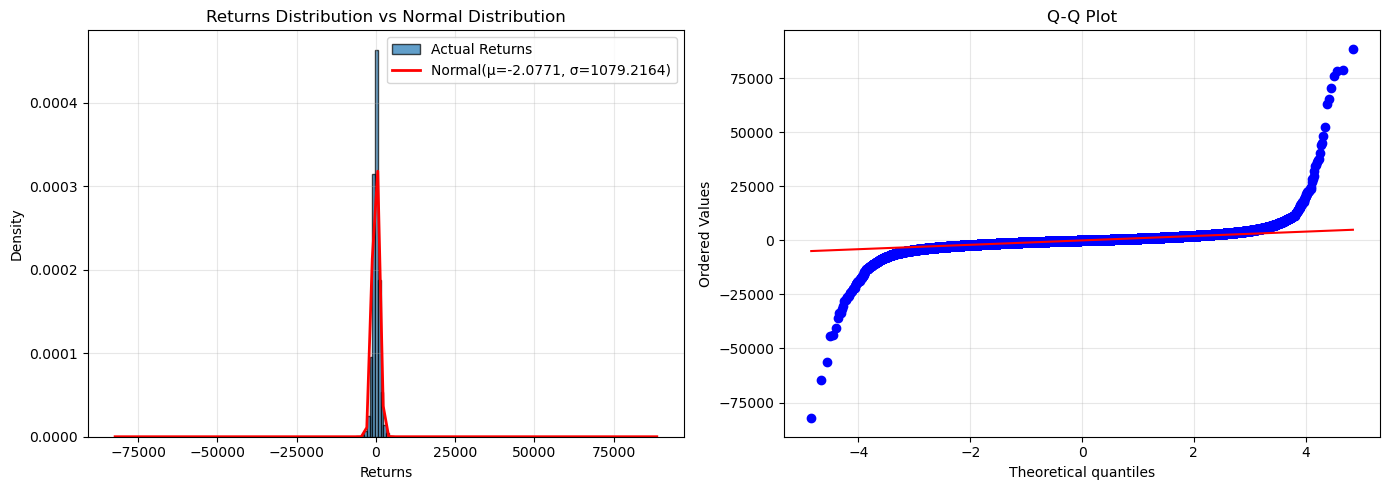

Mean: -2.077096
Std Dev: 1079.216428
Skewness: 1.6849
Kurtosis: 253.3982
Jarque-Bera test: statistic=2933863525.0651, p-value=0.0000


In [10]:
# Extract returns column (assuming it's already calculated)
vb_returns = vb_lf["delta_midpoint_vwap"].drop_nulls().to_numpy()

compare_distributions(vb_returns)

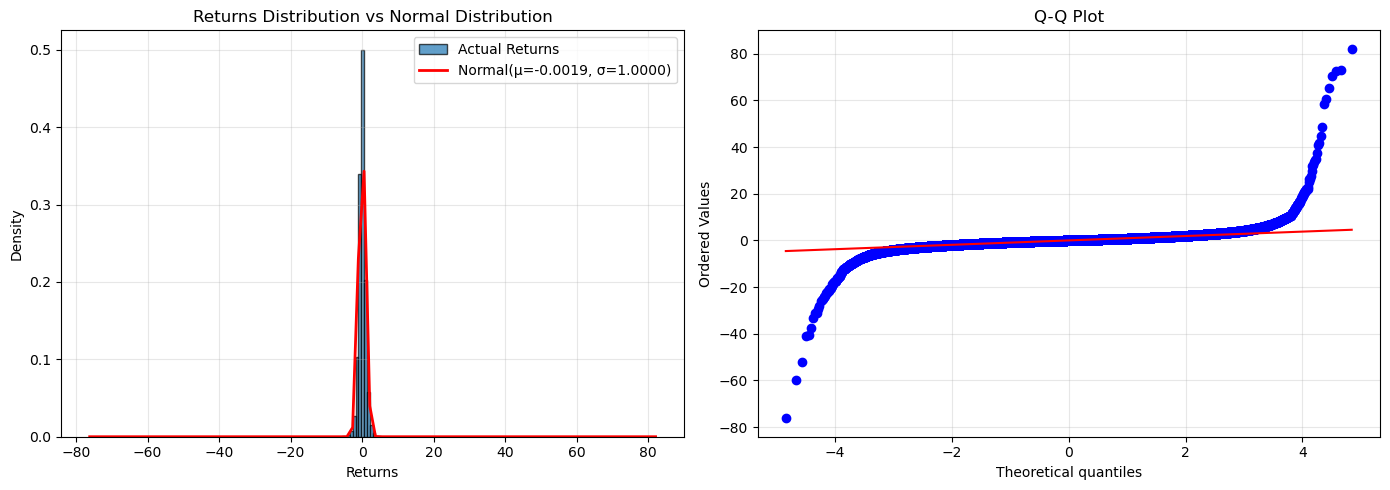

Mean: -0.001925
Std Dev: 1.000000
Skewness: 1.6849
Kurtosis: 253.3982
Jarque-Bera test: statistic=2933863525.0651, p-value=0.0000


In [11]:
# test dividing all values by std...
std_deltas = np.std(vb_returns)
normalized_deltas = vb_returns / std_deltas

compare_distributions(normalized_deltas)

In [12]:

IB1500_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_ib1500/2214_Nov_15_25/bucket/interval/bucket_interval_consolidated.parquet")

# ============================================================================
# [START] - Import Filters
# ============================================================================


# Convert START_DATE and END_DATE to nanosecond epochs (integers)
START_DATE_NS = int(datetime(2022, 1, 1, tzinfo=timezone.utc).timestamp() * 1e9)
END_DATE_NS   = int(datetime(2025, 1, 1, tzinfo=timezone.utc).timestamp() * 1e9)
# END_DATE_NS   = int(datetime(2025, 1, 1, tzinfo=timezone.utc).timestamp() * 1e9)


# Data files to glob for processing
IB_DATA_GLOB = pl.scan_parquet(str(IB1500_DIR))


# {IntervalBucket - 1500} [ ACTUAL FILTER REQUEST FOR PROCESSING ]
ib_lf = IB_DATA_GLOB.select([
    
    "id",
    "delta_midpoint_vwap_log_sum",

]).collect()


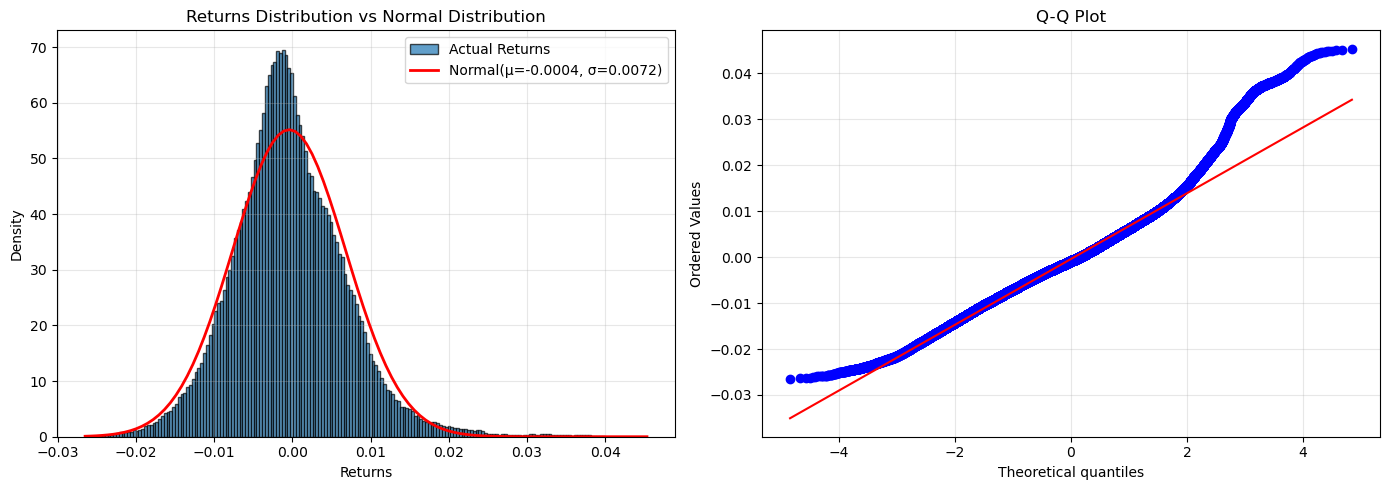

Mean: -0.000410
Std Dev: 0.007233
Skewness: 0.5745
Kurtosis: 1.9008
Jarque-Bera test: statistic=225060.0463, p-value=0.0000


In [13]:
# Extract returns column (assuming it's already calculated)
ib_returns = ib_lf["delta_midpoint_vwap_log_sum"].drop_nulls().to_numpy()

compare_distributions(ib_returns)

In [14]:
agg_vb_lf = VB_DATA_GLOB.with_columns(
    bucket=pl.int_range(pl.len()) // 30
).group_by("bucket").agg(
    buy_vwap=((pl.col("volume_buy") * pl.col("price_buy_vwap")).sum() / pl.col("volume_buy").sum()) / 1e9,
    sell_vwap=((pl.col("volume_sell") * pl.col("price_sell_vwap")).sum() / pl.col("volume_sell").sum()) / 1e9,
    delta_midpoint_vwap_log=pl.col("delta_midpoint_vwap_log").sum(),
).with_columns(
    total_vwap=(pl.col("buy_vwap") + pl.col("sell_vwap")) / 2,
    spread=pl.col("buy_vwap") - pl.col("sell_vwap")
).with_columns(
    prev_total_vwap=pl.col("total_vwap").shift(1),
    total_vwap_change=pl.col("total_vwap") - pl.col("total_vwap").shift(1),
    pct_return=(pl.col("total_vwap") - pl.col("total_vwap").shift(1)) / pl.col("total_vwap").shift(1),
    log_return=pl.col("total_vwap").log() - pl.col("total_vwap").shift(1).log()
).sort("bucket").drop("bucket").select([
    "delta_midpoint_vwap_log",
    "buy_vwap",
    "sell_vwap",
    "total_vwap",
    "spread",
    "prev_total_vwap",
    "total_vwap_change",
    "pct_return",
    "log_return"
]).collect()

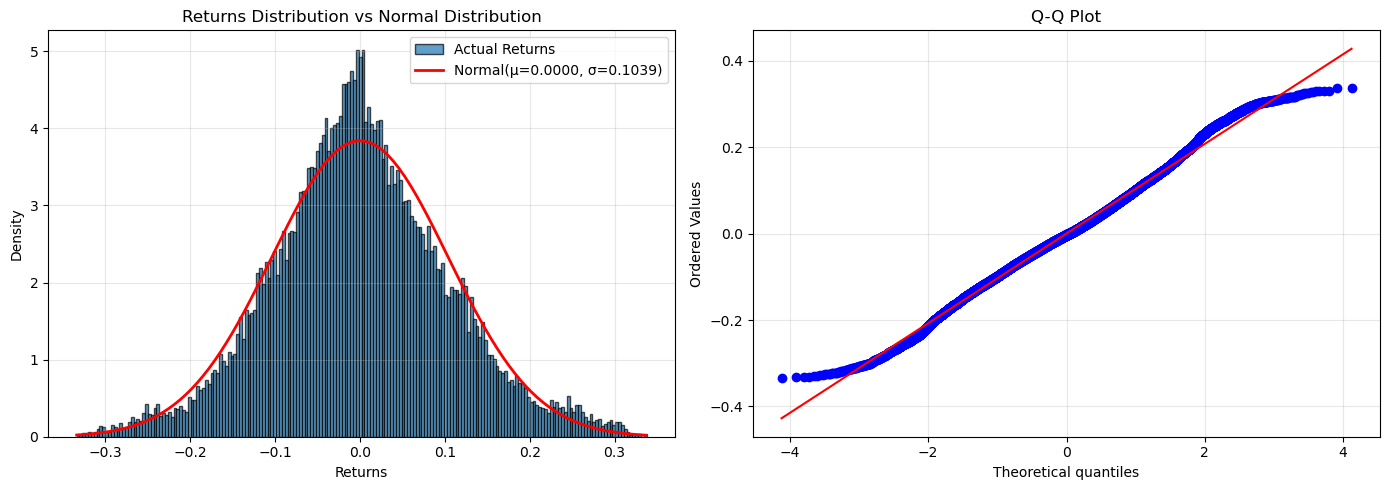

Mean: 0.000002
Std Dev: 0.103897
Skewness: 0.1105
Kurtosis: 0.3195
Jarque-Bera test: statistic=229.8711, p-value=0.0000


In [15]:
# Extract returns column (assuming it's already calculated)
agg_returns = agg_vb_lf["log_return"].drop_nulls().to_numpy()

compare_distributions(agg_returns)

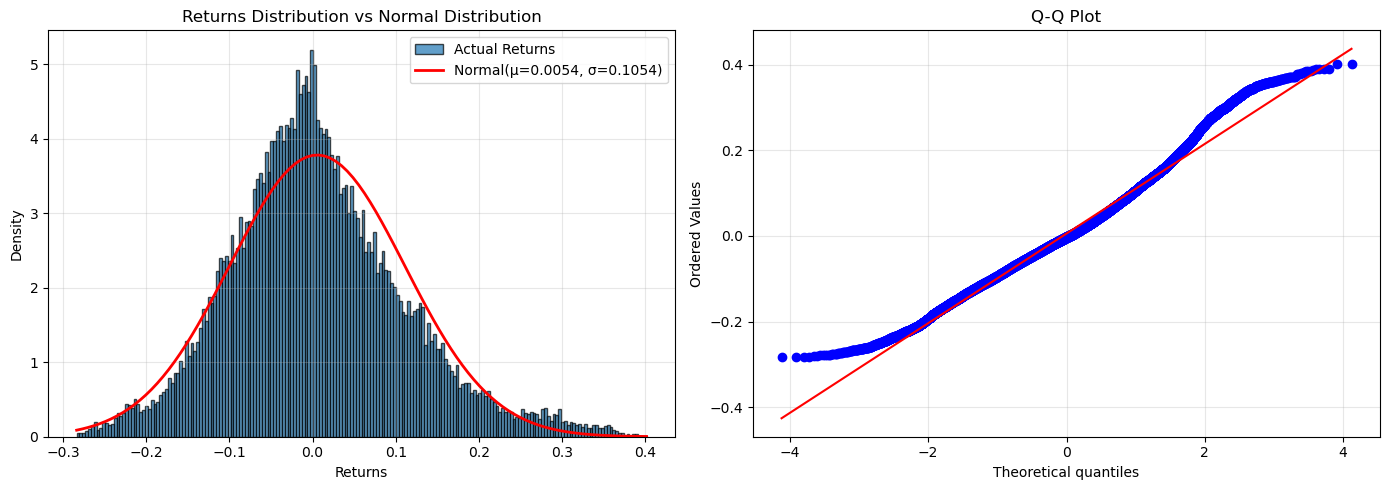

Mean: 0.005436
Std Dev: 0.105447
Skewness: 0.4701
Kurtosis: 0.5686
Jarque-Bera test: statistic=1838.4641, p-value=0.0000


In [16]:
# Extract returns column (assuming it's already calculated)
agg_returns3 = agg_vb_lf["pct_return"].drop_nulls().to_numpy()

compare_distributions(agg_returns3)

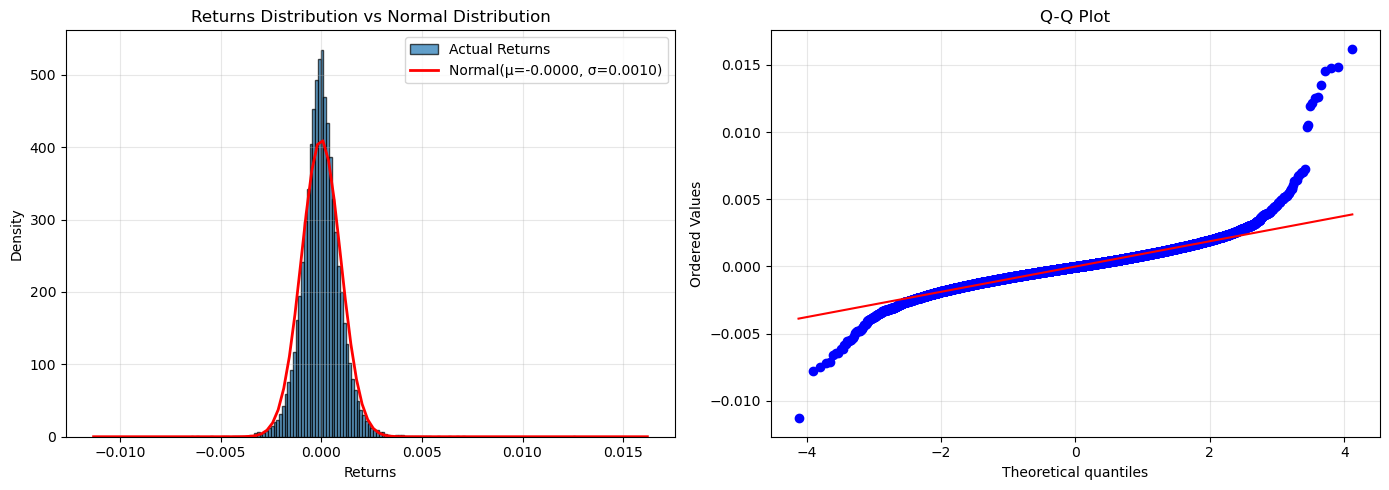

Mean: -0.000008
Std Dev: 0.000971
Skewness: 0.8724
Kurtosis: 14.2996
Jarque-Bera test: statistic=316012.4259, p-value=0.0000


In [17]:
# Extract returns column (assuming it's already calculated)
agg_returns2 = agg_vb_lf["delta_midpoint_vwap_log"].drop_nulls().to_numpy()

compare_distributions(agg_returns2)

In [18]:


plt.figure(figsize=(10, 6))
plt.hist(agg_vb_lf2["total_time"], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Duration (hours)')
plt.ylabel('Frequency')
plt.title('Distribution of Duration')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'agg_vb_lf2' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import gaussian_kde
import polars as pl

def plot_distribution_comparison(log_returns_a, log_returns_b, figsize=(16, 8)):
    """
    Create Bloomberg-styled comparison of two log return distributions vs standard normal.
    
    Parameters:
    -----------
    log_returns_a : list or array-like
        Log returns for Distribution A
    log_returns_b : list or array-like
        Log returns for Distribution B
    figsize : tuple
        Figure dimensions
    """
    
    # Apply Bloomberg theme
    plt.rcParams.update({
        'figure.facecolor': '#0a0e27',
        'axes.facecolor': '#0f1419',
        'axes.edgecolor': '#1e2332',
        'axes.labelcolor': '#b3b8c4',
        'axes.titlecolor': '#ffffff',
        'text.color': '#e8eaed',
        'xtick.color': '#7e8391',
        'ytick.color': '#7e8391',
        'grid.color': '#1e2332',
        'grid.linestyle': '--',
        'grid.linewidth': 0.5,
        'grid.alpha': 0.3,
        'figure.dpi': 150,
        'axes.grid': True,
        'axes.axisbelow': True,
        'font.family': 'sans-serif',
        'font.size': 10,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'lines.linewidth': 2.0,
    })
    
    # Convert to numpy arrays
    data_a = np.array(log_returns_a)
    data_b = np.array(log_returns_b)
    
    # Remove NaN values
    data_a = data_a[~np.isnan(data_a)]
    data_b = data_b[~np.isnan(data_b)]
    
    # Standardize data
    data_a_std = (data_a - np.mean(data_a)) / np.std(data_a)
    data_b_std = (data_b - np.mean(data_b)) / np.std(data_b)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.patch.set_facecolor('#0a0e27')
    
    # --- LEFT PANEL: Kernel Density Estimation ---
    
    # Generate KDE for both distributions
    kde_a = gaussian_kde(data_a_std)
    kde_b = gaussian_kde(data_b_std)
    
    # Create evaluation points
    x_min = min(data_a_std.min(), data_b_std.min(), -4)
    x_max = max(data_a_std.max(), data_b_std.max(), 4)
    x_eval = np.linspace(x_min, x_max, 500)
    
    # Evaluate densities
    density_a = kde_a(x_eval)
    density_b = kde_b(x_eval)
    
    # Standard normal density
    normal_density = stats.norm.pdf(x_eval)
    
    # Plot distributions

    ax1.plot(x_eval, density_a, color='#ffd93d', linewidth=2, label='Time-Bars')
    ax1.plot(x_eval, normal_density, color='#ff6b6b', linewidth=2.5, linestyle='--', alpha=0.8, label='Standard Normal')
    ax1.plot(x_eval, density_b, color='#00d4aa', linewidth=2.5, label='Volume-Bars')
    
    # Optional gradient fills
    # ax1.fill_between(x_eval, density_a, alpha=0.15, color='#ffd93d')
    ax1.fill_between(x_eval, density_b, alpha=0.15, color='#00d4aa')
    
    # Formatting
    ax1.set_xlabel('Standardized Log Returns', fontsize=11, color='#b3b8c4')
    ax1.set_ylabel('Density', fontsize=11, color='#b3b8c4')
    ax1.set_title('Kernel Density Estimation', fontsize=14, fontweight='bold', color='#ffffff')
    
    # Remove top and right spines
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#1e2332')
    ax1.spines['bottom'].set_color('#1e2332')
    
    # Legend
    ax1.legend(loc='upper right', framealpha=0.95, facecolor='#0f1419', 
               edgecolor='#1e2332', fontsize=10)
    
    # Grid
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax1.set_axisbelow(True)
    
    # --- RIGHT PANEL: Q-Q Plots ---
    
    # Generate theoretical quantiles
    n_a = len(data_a_std)
    n_b = len(data_b_std)
    
    # Sort data
    sorted_a = np.sort(data_a_std)
    sorted_b = np.sort(data_b_std)
    
    # Theoretical quantiles
    theoretical_a = stats.norm.ppf(np.linspace(0.01, 0.99, n_a))
    theoretical_b = stats.norm.ppf(np.linspace(0.01, 0.99, n_b))
    
    # Plot Q-Q for Distribution A
    ax2.scatter(theoretical_a, sorted_a, color='#ffd93d', s=20, 
                alpha=0.6, label='Time-Bars', edgecolors='none')
    
    # Plot Q-Q for Distribution B
    ax2.scatter(theoretical_b, sorted_b, color='#00d4aa', s=20, 
                alpha=0.6, label='Volume-Bars', edgecolors='none')
    
    # Reference line (perfect normal)
    lims = [
        np.min([ax2.get_xlim(), ax2.get_ylim()]),
        np.max([ax2.get_xlim(), ax2.get_ylim()]),
    ]

    ax2.plot(lims, lims, color='#ff6b6b', linestyle='--', linewidth=2.5, 
             alpha=1, label='Perfect Normal')
    
    # Formatting
    ax2.set_xlabel('Theoretical Quantiles', fontsize=11, color='#b3b8c4')
    ax2.set_ylabel('Sample Quantiles', fontsize=11, color='#b3b8c4')
    ax2.set_title('Q-Q Plot vs Standard Normal', fontsize=14, fontweight='bold', color='#ffffff')
    
    # Remove top and right spines
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_color('#1e2332')
    ax2.spines['bottom'].set_color('#1e2332')
    
    # Legend
    ax2.legend(loc='upper left', framealpha=0.95, facecolor='#0f1419', 
               edgecolor='#1e2332', fontsize=10)
    
    # Grid
    ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax2.set_axisbelow(True)
    
    # Set aspect to be equal for Q-Q plot
    ax2.set_aspect('equal', adjustable='box')
    
    # Tight layout
    plt.tight_layout()
    
    return fig, (ax1, ax2)


# Example usage with Polars DataFrame:
# df = pl.read_csv('data.csv')
# log_returns_a = df['log_return_a'].to_list()
# log_returns_b = df['log_return_b'].to_list()
# fig, axes = plot_distribution_comparison(log_returns_a, log_returns_b)
# plt.show()

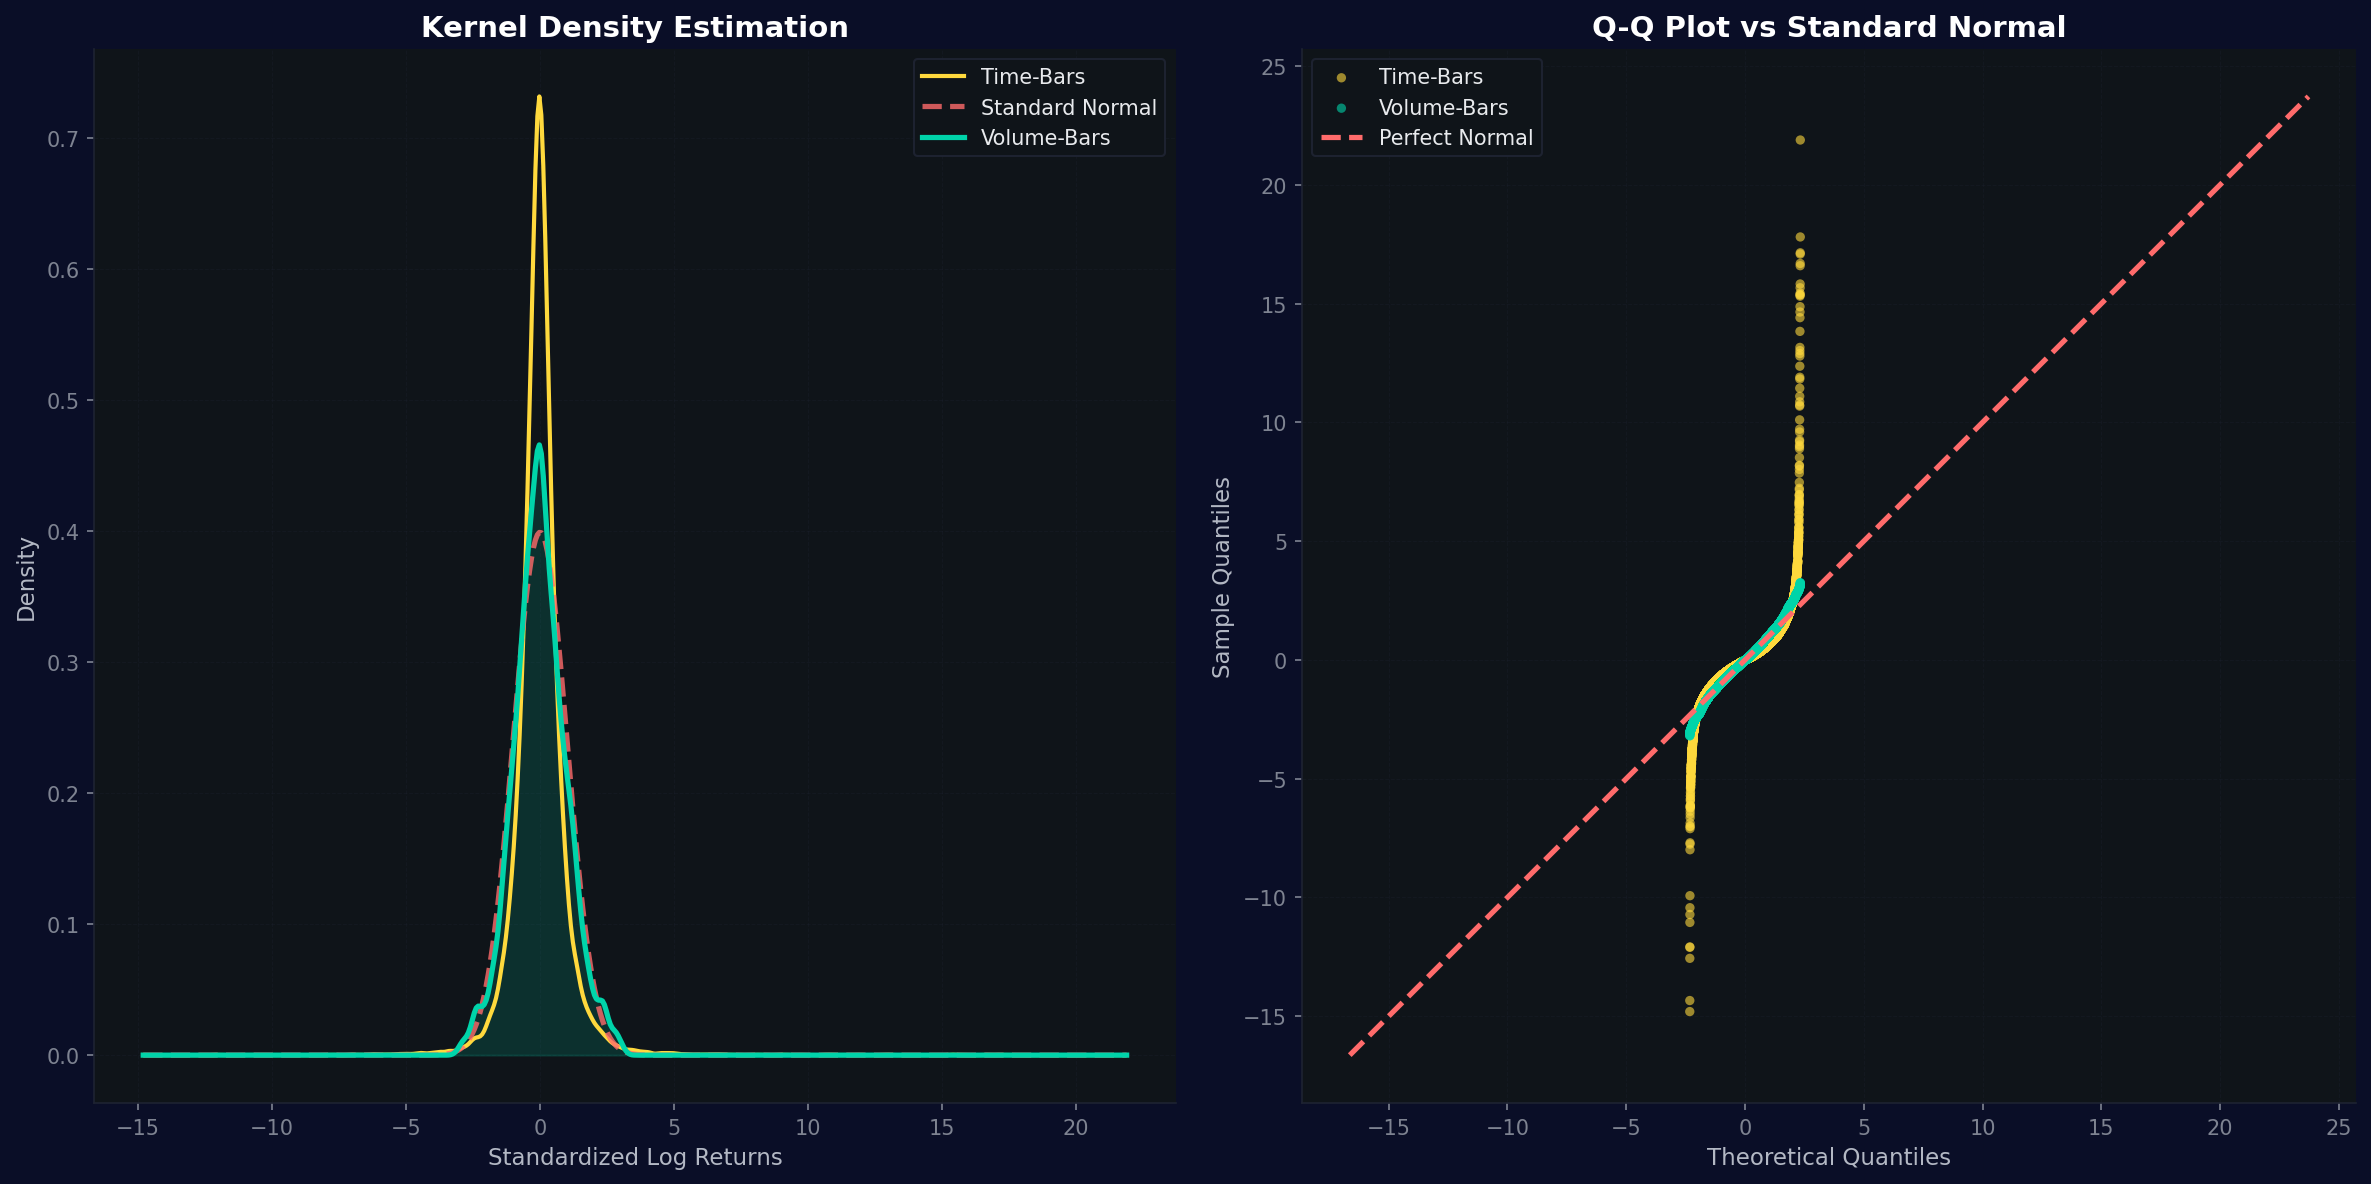

In [ ]:
fig, axes = plot_distribution_comparison(timebar_returns, agg_returns)
plt.show()